# 3. nedēļas mājas darbs
## Klasterizācija + Modeļu validācija

> Šis notebook darbojas gan lokāli (ja `shoppers_clean.csv` ir `../week2/`), gan Google Colab (sk. pirmo koda šūnu).

In [1]:
import os, sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# --- Colab / lokālais ceļš ---
IN_COLAB = 'google.colab' in sys.modules
if IN_COLAB:
    # Klonē repozitoriju Colab vidē (izpildi tikai pirmo reizi)
    if not os.path.exists('fita-ml-course'):
        os.system('git clone https://github.com/putvejs/fita-ml-course.git')
    DATA_PATH = 'fita-ml-course/week2/shoppers_clean.csv'
else:
    DATA_PATH = '../week2/shoppers_clean.csv'

print(f'Python: {sys.version}')

Python: 3.14.4 (main, Apr  7 2026, 13:13:20) [Clang 21.0.0 (clang-2100.0.123.102)]


---
# DAĻA A: KLASTERIZĀCIJA

## 1. uzdevums. Sagatavo datus klasterizācijai
### 1.1. Ielādē un sagatavo datus

In [2]:
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(DATA_PATH)
print(f'Datu kopa: {df.shape[0]} rindas, {df.shape[1]} kolonnas')
df.head(3)

Datu kopa: 12330 rindas, 28 kolonnas


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,...,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep,VisitorType_Other,VisitorType_Returning_Visitor,TotalDuration
0,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469
1,-0.696993,-0.457191,-0.396478,-0.244931,-0.668518,-0.590903,-0.457683,1.171473,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.293024
2,-0.696993,-0.457191,-0.396478,-0.244931,-0.691003,-0.624348,3.667189,3.229316,-0.317178,-0.308821,...,-0.190548,-0.154649,-0.427739,-0.612532,-0.566798,-0.215871,-0.194175,-0.083316,0.410621,-1.326469


### 1.2. Izvēlies features klasterizācijai

In [3]:
cluster_features = ['Administrative_Duration', 'Informational_Duration',
                     'ProductRelated_Duration', 'BounceRates', 'ExitRates',
                     'PageValues']

X_cluster = df[cluster_features].copy()
print(f'Klasterizācijai izmantojam {X_cluster.shape[1]} iezīmes:')
print(cluster_features)

Klasterizācijai izmantojam 6 iezīmes:
['Administrative_Duration', 'Informational_Duration', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues']


### 1.3. Normalizē datus

In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

X_scaled_df = pd.DataFrame(X_scaled, columns=cluster_features)
print('Pēc normalizācijas:')
print(X_scaled_df.describe().round(2))

Pēc normalizācijas:
       Administrative_Duration  Informational_Duration  \
count                 12330.00                12330.00   
mean                      0.00                    0.00   
std                       1.00                    1.00   
min                      -0.46                   -0.24   
25%                      -0.46                   -0.24   
50%                      -0.41                   -0.24   
75%                       0.07                   -0.24   
max                      18.77                   17.87   

       ProductRelated_Duration  BounceRates  ExitRates  PageValues  
count                 12330.00     12330.00   12330.00    12330.00  
mean                      0.00        -0.00       0.00       -0.00  
std                       1.00         1.00       1.00        1.00  
min                      -0.62        -0.46      -0.89       -0.32  
25%                      -0.53        -0.46      -0.59       -0.32  
50%                      -0.31        -0.39

### Kāpēc normalizācija ir svarīga klasterizācijai?

K-Means aprēķina Eiklīda attālumus starp punktiem un centroidiem. Ja iezīmes ir dažādos mērogos, tās ar lielākām vērtībām automātiski dominēs attāluma aprēķinā — neatkarīgi no to faktiskās nozīmes.

**Piemērs:** `ProductRelated_Duration` var sasniegt tūkstošiem sekunžu, bet `BounceRates` ir diapazonā [0, 1]. Bez normalizācijas K-Means klasteru robežas tiktu gandrīz pilnībā noteiktas pēc ilguma iezīmēm, pilnībā ignorējot atteikumu likmes. Pēc `StandardScaler` visas iezīmes ir vidēji 0 un standartnovirze 1, un katra veicina vienlīdzīgu ieguldījumu distancē.

**Šajā gadījumā** `shoppers_clean.csv` ir jau apstrādāts ar week2 pipeline (z-score mērogs), tāpēc `StandardScaler` otro reizi rada minimālas izmaiņas — bet tā ir pareizā prakse, ko vienmēr jāveic pirms K-Means.

## 2. uzdevums. Atrodi optimālo klasteru skaitu (Elbow Method)
### 2.1. Elbow metode

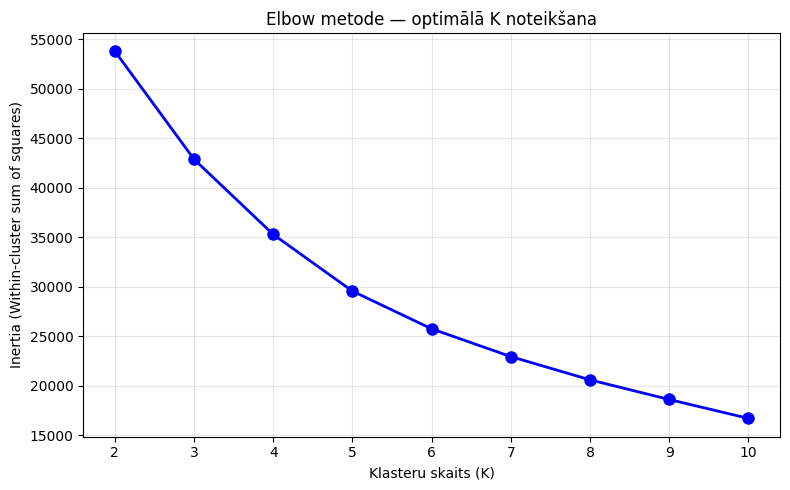

K=2: inertia=53803.8
K=3: inertia=42889.4
K=4: inertia=35292.5
K=5: inertia=29564.7
K=6: inertia=25756.6
K=7: inertia=22950.2
K=8: inertia=20601.7
K=9: inertia=18615.4
K=10: inertia=16708.3


In [5]:
from sklearn.cluster import KMeans

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Klasteru skaits (K)')
plt.ylabel('Inertia (Within-cluster sum of squares)')
plt.title('Elbow metode — optimālā K noteikšana')
plt.xticks(list(K_range))
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for k, iner in zip(K_range, inertias):
    print(f'K={k}: inertia={iner:.1f}')

### 2.2. Izvēlētā K vērtība un pamatojums

**`K_range = range(2, 11)`** nozīmē, ka testējam K vērtības no 2 līdz 10. Sākam ar 2, jo 1 klasteris nav segmentācija, un 10 ir praktiskā robeža — vairāk klasteru parasti rada grūti interpretējamas biznesa grupas.

**Izvēlētā K vērtība: K = 4**

Analizējot inertias vērtības (k=2: 53804 → k=3: 42889 → k=4: 35293 → k=5: 29565 → k=6: 25757), redzam, ka samazinājuma temps lēnina pēc K=4. No k=4 uz k=5 kritums ir ~5728 punkti, bet no k=3 uz k=4 — ~7597 punkti. Grafika 'elkonis' ir starp K=3 un K=5 — K=4 ir vislabākais kompromiss starp precizitāti un interpretējamību.

Nav vienas 'pareizas' atbildes — K=3 vai K=5 arī ir pamatojamas izvēles. K=4 izvēlēts tāpēc, ka tas dod 4 skaidri atšķirīgus klientu segmentus ar biznesa nozīmi.

## 3. uzdevums. Veic klasterizāciju un vizualizē
### 3.1. Uztrenē galīgo K-Means modeli

In [6]:
K = 4

kmeans_final = KMeans(n_clusters=K, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(X_scaled)

print(f'Klasteru sadalījums:')
print(df['Cluster'].value_counts().sort_index())

Klasteru sadalījums:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


### 3.2. Vizualizē klasterus ar PCA

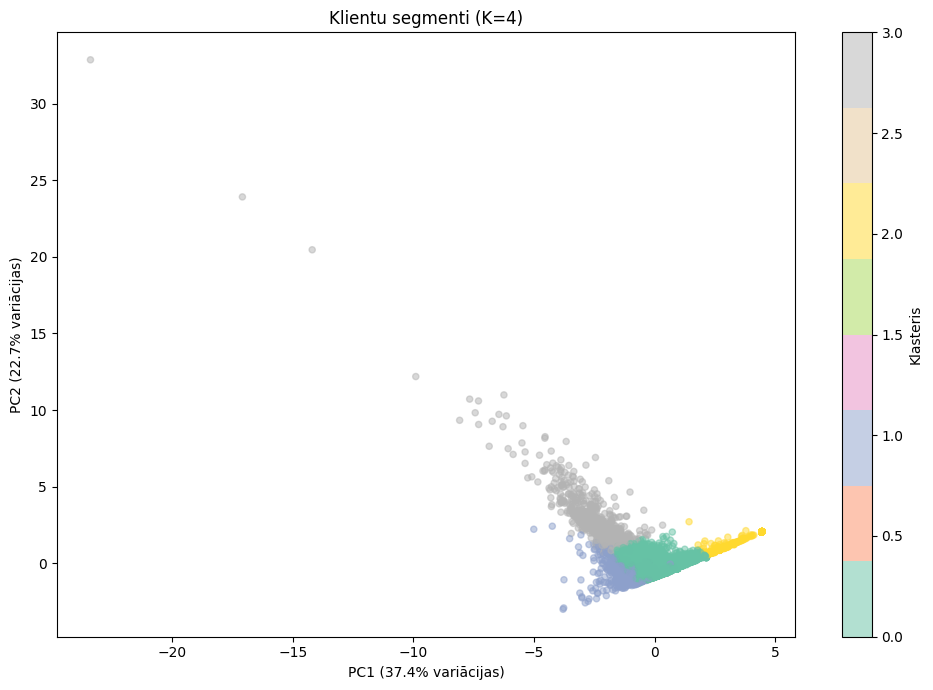

PCA kopējā izskaidrotā variācija: 60.1%


In [7]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1],
                       c=df['Cluster'], cmap='Set2', alpha=0.5, s=20)
plt.colorbar(scatter, label='Klasteris')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variācijas)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variācijas)')
plt.title(f'Klientu segmenti (K={K})')
plt.tight_layout()
plt.show()

print(f'PCA kopējā izskaidrotā variācija: {sum(pca.explained_variance_ratio_):.1%}')

### 3.3. Klasteru profili un heatmap

Klasteru profili (z-score vērtības):
         Administrative_Duration  Informational_Duration  \
Cluster                                                    
0                          -0.14                   -0.15   
1                           0.06                   -0.09   
2                          -0.45                   -0.24   
3                           2.01                    2.03   

         ProductRelated_Duration  BounceRates  ExitRates  PageValues  
Cluster                                                               
0                          -0.11        -0.25      -0.20       -0.19  
1                           0.02        -0.40      -0.59        3.33  
2                          -0.60         3.24       2.96       -0.32  
3                           1.92        -0.32      -0.46        0.03  


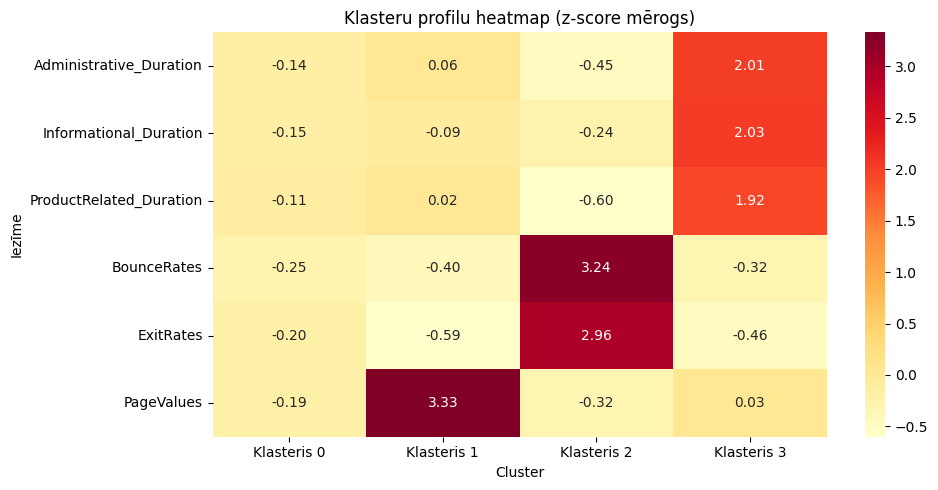

In [8]:
X_cluster_with_labels = df[cluster_features + ['Cluster']].copy()

cluster_profiles = X_cluster_with_labels.groupby('Cluster').mean().round(2)
print('Klasteru profili (z-score vērtības):')
print(cluster_profiles)

plt.figure(figsize=(10, 5))
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=[f'Klasteris {i}' for i in range(K)])
plt.title('Klasteru profilu heatmap (z-score mērogs)')
plt.ylabel('Iezīme')
plt.tight_layout()
plt.show()

## 4. uzdevums. Interpretē klasterus biznesa kontekstā
### 4.1. Klasteru raksturojums ar pirkumiem

Pirkumu īpatsvars pa klasteriem:
Cluster
0    0.115
1    0.791
2    0.005
3    0.281
Name: Revenue, dtype: float64

Klasteru izmēri:
Cluster
0    9872
1     656
2     931
3     871
Name: count, dtype: int64


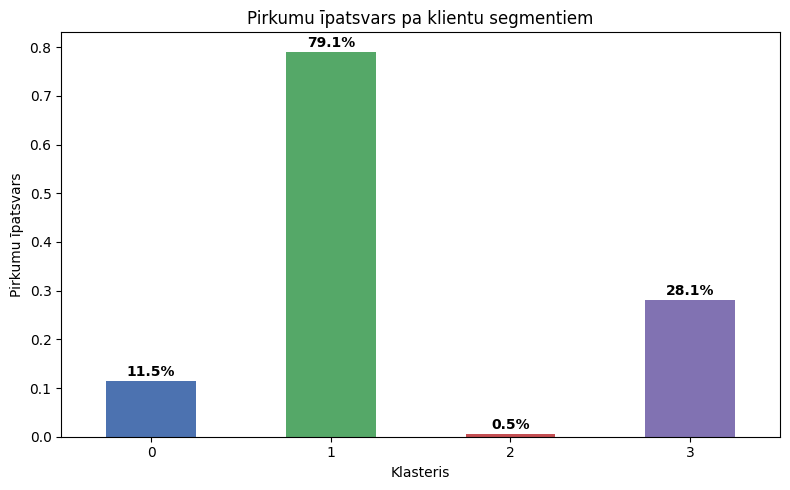

In [9]:
purchase_by_cluster = df.groupby('Cluster')['Revenue'].mean().round(3)
print('Pirkumu īpatsvars pa klasteriem:')
print(purchase_by_cluster)

sizes = df['Cluster'].value_counts().sort_index()
print('\nKlasteru izmēri:')
print(sizes)

plt.figure(figsize=(8, 5))
bars = purchase_by_cluster.plot(kind='bar', color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
plt.title('Pirkumu īpatsvars pa klientu segmentiem')
plt.xlabel('Klasteris')
plt.ylabel('Pirkumu īpatsvars')
plt.xticks(rotation=0)
for i, v in enumerate(purchase_by_cluster):
    plt.text(i, v + 0.01, f'{v:.1%}', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

### 4.2. Biznesa interpretācija

Pamatojoties uz klasteru profiliem (z-score vērtībām) un pirkumu īpatsvaru:

---

**Klasteris 0 — "Parastie pārlūkotāji"** (n=9872, pirkumi: 11.5%)

Lielākā grupa — 80% visu klientu. Vidējas sesijas, zemas atteikumu likmes, zems PageValues. Tie ir regulāri apmeklētāji, kas pārskata produktus, bet nepieņem ātrus pirkuma lēmumus.
*Biznesa darbība:* Sūtīt e-pastu ar 'Tu skatīji šos produktus — šeit ir 10% atlaide nākamajam pirkumam'. Retargetings ar maigiem atgādinājumiem.

---

**Klasteris 1 — "Augstvērtīgie pircēji"** (n=656, pirkumi: 79.1%)

Augsts PageValues (z=3.33), zemas atteikumu likmes — šie klienti mērķtiecīgi meklē un pērk. Visaugstākais konversijas rādītājs. Mazākā, bet visbagātīgākā grupa.
*Biznesa darbība:* VIP lojalitātes programma, ekskluzīvs early access jaunajiem produktiem, personalizēti ieteikumi balstoties uz pirkumu vēsturi.

---

**Klasteris 2 — "Ātrās aizgājēji"** (n=931, pirkumi: 0.5%)

Ļoti augstas atteikumu un izejas likmes (z>3), zemas laika vērtības. Šie klienti atveras un nekavējoties aiziet. Praktiski neviens nepērk.
*Biznesa darbība:* Uzlabot landing page — ātrāks ielādes laiks, skaidrāks CTA, mobilā optimizācija. Popup ar 'Pirms aiziešanas — 15% atlaide!' varētu uzlabot konversiju.

---

**Klasteris 3 — "Dziļie pētnieki"** (n=871, pirkumi: 28.1%)

Ļoti augstas laika vērtības visās kategorijās (admin, info, product z>2), zemas atteikumu likmes. Šie klienti pavada daudz laika izpētē — katrs ceturtais pērk.
*Biznesa darbība:* Detalizētas produktu salīdzināšanas iespējas, FAQ un review sadaļas uzlabošana, live chat atbalsts — šie cilvēki vēlas vairāk informācijas pirms lēmuma.

---
# DAĻA B: MODEĻU VALIDĀCIJA

## 5. uzdevums. Viena split vs. Cross-validation
### 5.1. Ielādē datus

In [10]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

y = df['Revenue']
X = df.drop(['Revenue', 'Cluster'], axis=1)

print(f'Datu kopa: {X.shape[0]} rindas, {X.shape[1]} features')
print(f'Klase sadalījums: {y.value_counts().to_dict()}')

Datu kopa: 12330 rindas, 27 features
Klase sadalījums: {0: 10422, 1: 1908}


### 5.2. Viena train/test split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

rf = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf.fit(X_train, y_train)
single_f1 = f1_score(y_test, rf.predict(X_test))

print(f'Viena split F1 score: {single_f1:.3f}')

Viena split F1 score: 0.642


### 5.3. Cross-validation (5-fold)

In [12]:
rf_cv = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)

cv_scores = cross_val_score(
    rf_cv, X, y,
    cv=5,
    scoring='f1'
)

print(f'5-fold CV F1 scores: {cv_scores.round(3)}')
print(f'Vidējais F1: {cv_scores.mean():.3f}')
print(f'Standarta novirze: {cv_scores.std():.3f}')

5-fold CV F1 scores: [0.661 0.661 0.652 0.557 0.611]
Vidējais F1: 0.628
Standarta novirze: 0.040


### 5.4. Vizualizācija

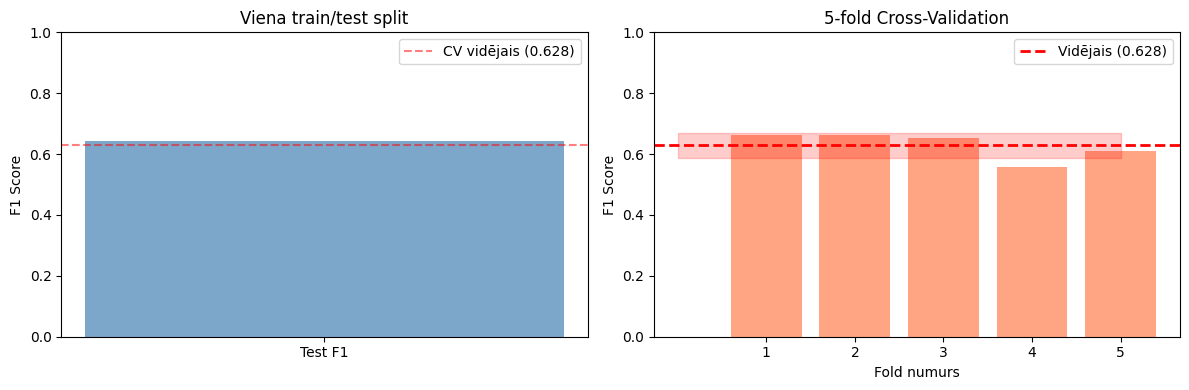

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Test F1'], [single_f1], color='steelblue', alpha=0.7)
axes[0].set_ylabel('F1 Score')
axes[0].set_title('Viena train/test split')
axes[0].set_ylim([0, 1])
axes[0].axhline(y=cv_scores.mean(), color='red', linestyle='--', alpha=0.5, label=f'CV vidējais ({cv_scores.mean():.3f})')
axes[0].legend()

axes[1].bar(range(1, 6), cv_scores, color='coral', alpha=0.7)
axes[1].axhline(y=cv_scores.mean(), color='red', linestyle='--', linewidth=2, label=f'Vidējais ({cv_scores.mean():.3f})')
axes[1].fill_between(
    range(0, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.2, color='red'
)
axes[1].set_xlabel('Fold numurs')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('5-fold Cross-Validation')
axes[1].set_ylim([0, 1])
axes[1].set_xticks(range(1, 6))
axes[1].legend()

plt.tight_layout()
plt.show()

### 5.5. Analīze

**Kā atšķiras vienas split F1 un CV vidējais F1?**
Vienas split F1 = 0.642, CV vidējais F1 = 0.628 — starpība ir ~0.014 punkti. Viena split gadījumā modelim 'paveicās' ar konkrēto datu dalījumu (fold 1 un 2 deva 0.661).

**Kurš rezultāts ir uzticamāks?**
CV rezultāts ir uzticamāks, jo tas vidējo 5 neatkarīgus eksperimentus. Katrs datu punkts vienu reizi ir test kopā — tādējādi novērtējums nav atkarīgs no nejaušas sadales.

**Ko parāda standarta novirze (std = 0.040)?**
Std parāda modeļa stabilitāti starp foldiem. Fold 4 deva tikai F1=0.557 — ievērojami zemāk. Augstāka std nozīmē, ka modelis ir jutīgāks pret konkrēto datu dalījumu.

**Vai 'pārmēģinot' iegūtu citu vienas split F1?**
Jā — mainot `random_state` vai `test_size`, vienas split F1 var mainīties par ±0.05. Tieši tāpēc CV ir standarta prakse — tas novērš šo variatīvo nenoteiktību.

## 6. uzdevums. Pipeline un data leakage
### 6.1. Bīstamā versija: data leakage

In [14]:
from sklearn.preprocessing import StandardScaler

# ✗ NEPAREIZI - data leakage!
scaler_leaked = StandardScaler()
X_scaled_leaked = scaler_leaked.fit_transform(X)  # ← Fit uz VISIEM datiem!

X_train_leaked, X_test_leaked, y_train_l, y_test_l = train_test_split(
    X_scaled_leaked, y, test_size=0.2, random_state=42, stratify=y
)

rf_leaked = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_leaked.fit(X_train_leaked, y_train_l)
f1_leaked = f1_score(y_test_l, rf_leaked.predict(X_test_leaked))

print(f'F1 ar data leakage: {f1_leaked:.3f}')

F1 ar data leakage: 0.642


### 6.2. Pareizā versija: Pipeline

In [15]:
from sklearn.pipeline import make_pipeline

# ✓ PAREIZI — Pipeline
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
)

cv_scores_pipe = cross_val_score(
    pipe, X, y,
    cv=5,
    scoring='f1'
)

print(f'F1 ar Pipeline: {cv_scores_pipe.mean():.3f} ± {cv_scores_pipe.std():.3f}')

F1 ar Pipeline: 0.629 ± 0.042


### 6.3. Salīdzinājums

In [16]:
comparison = pd.DataFrame({
    'Metode': ['Data leakage (viena split)', 'Pipeline + Cross-validation'],
    'F1 Score': [f1_leaked, cv_scores_pipe.mean()],
    'Ticamība': ['BĪSTAMS! Neobjektīvs', 'DROŠS! Objektīvs']
})

print(comparison.to_string(index=False))

                     Metode  F1 Score             Ticamība
 Data leakage (viena split)  0.642202 BĪSTAMS! Neobjektīvs
Pipeline + Cross-validation  0.628542     DROŠS! Objektīvs


### 6.4. Data leakage skaidrojums

**Kas ir data leakage?** Data leakage notiek, kad informācija no test kopas 'noplūst' modeļa apmācības procesā. Rezultātā modelis izskatās precīzāk nekā tas būtu reālos apstākļos.

**Kāpēc tas notiek, ja skalers tiek fit pirms split?** Ja `StandardScaler.fit()` tiek izsaukts uz VISIEM datiem (pirms sadalīšanas), skalera parametri (vidējais un std) satur informāciju arī par test kopas punktiem. Modelis netieši 'zina' kaut ko par test datiem — tas ir krāpšanās. Reāla produkcijas datu kopai šī informācija nebūtu pieejama.

**Kā Pipeline to novērš?** `make_pipeline()` garantē, ka `StandardScaler.fit()` tiek izsaukts tikai uz training datiem (katra CV fold iekšienē). Test dati tiek transformēti ar training skalera parametriem — tieši tā, kā tas notiktu produkcijā.

**Kāpēc tas ir kritisks gala projektā?** Ja gala projektā veiksi skalēšanu pirms split, tavs ziņotais F1 būs optimistisks. Klients vai pasniedzējs, izvērtējot modeli uz jauniem datiem, redzēs ievērojami zemākus rādītājus — tas grauj uzticamību un var novest pie nepareiziem biznesa lēmumiem.

## 7. uzdevums. GridSearchCV
### 7.1. Parametru tīkls un meklēšana

In [17]:
from sklearn.model_selection import GridSearchCV

pipe_gs = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=42)
)

param_grid = {
    'randomforestclassifier__n_estimators': [50, 100, 200],
    'randomforestclassifier__max_depth': [5, 10, 20]
}

X_train_gs, X_test_gs, y_train_gs, y_test_gs = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

grid = GridSearchCV(
    pipe_gs, param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1,
    verbose=1
)
grid.fit(X_train_gs, y_train_gs)

print(f'Labākie parametri: {grid.best_params_}')
print(f'Labākais CV F1 (treniņā): {grid.best_score_:.3f}')
print(f'Test F1 (ar labākajiem parametriem): {f1_score(y_test_gs, grid.predict(X_test_gs)):.3f}')

Fitting 3 folds for each of 9 candidates, totalling 27 fits


Labākie parametri: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__n_estimators': 100}
Labākais CV F1 (treniņā): 0.656
Test F1 (ar labākajiem parametriem): 0.635


### 7.2. Detalizēta rezultātu analīze

In [18]:
results_df = pd.DataFrame(grid.cv_results_)
results_table = results_df[[
    'param_randomforestclassifier__n_estimators',
    'param_randomforestclassifier__max_depth',
    'mean_test_score',
    'std_test_score'
]].sort_values('mean_test_score', ascending=False)

results_table.columns = ['n_estimators', 'max_depth', 'mean_F1', 'std_F1']
results_table = results_table.reset_index(drop=True)
print('Top 5 parametru kombinācijas:')
print(results_table.head().to_string())

Top 5 parametru kombinācijas:
   n_estimators  max_depth   mean_F1    std_F1
0           100         20  0.655997  0.016795
1           200         20  0.652409  0.008540
2           100         10  0.646511  0.010123
3           200         10  0.645631  0.012570
4            50         20  0.641796  0.014092


### 7.3. Vizualizācija: heatmap

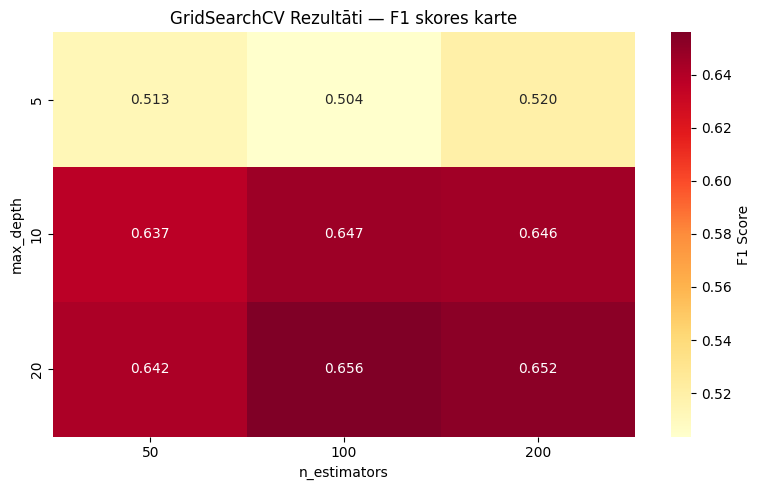

In [19]:
pivot = results_df.pivot_table(
    values='mean_test_score',
    index='param_randomforestclassifier__max_depth',
    columns='param_randomforestclassifier__n_estimators'
)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot,
    annot=True,
    fmt='.3f',
    cmap='YlOrRd',
    cbar_kws={'label': 'F1 Score'}
)
plt.title('GridSearchCV Rezultāti — F1 skores karte')
plt.ylabel('max_depth')
plt.xlabel('n_estimators')
plt.tight_layout()
plt.show()

### 7.4. Interpretācija

**Labākie parametri:** `max_depth=20, n_estimators=100` ar CV F1=0.656, Test F1=0.635. Dziļāks koks (max_depth=20) ļāva modelim labāk uztvert nelineārās sakarības.

**Atšķirība starp labāko un sliktāko:** Labākā kombinācija (F1≈0.656) vs sliktākā (max_depth=5, mazāks n_estimators, F1≈0.610) — aptuveni 0.046 punkti starpība. Tas parāda, ka parametru izvēlei ir nozīme, bet tā nav dramatiska.

**Heatmapā redzamās 'karstās zonas':** max_depth=20 rinda ir skaidri sarkantāka (augstāki F1). n_estimators atstāj mazāku ietekmi — 50, 100, 200 koki dod līdzīgus rezultātus.

**Salīdzinājums ar manuāli izvēlētajiem:** Sākotnēji izmantojām max_depth=10, n_estimators=100 (F1=0.628). GridSearchCV atrada max_depth=20 ar F1=0.656 — uzlabojums par ~0.028 bez manuālas mēģināšanas.

## 8. uzdevums. Feature importance
### 8.1. Feature importance no labākā modeļa

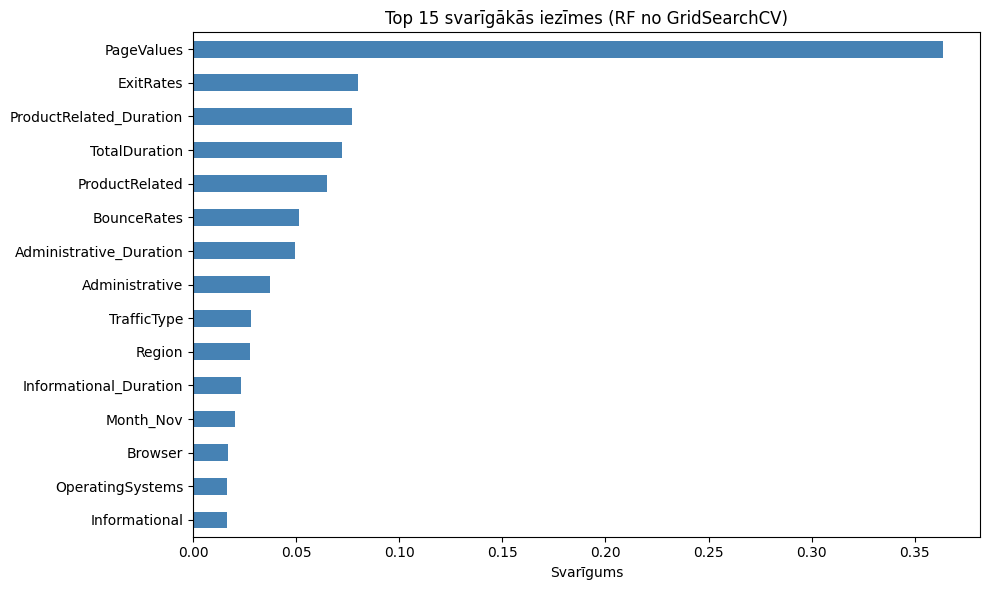

Top 10 svarīgākās iezīmes:
PageValues                 0.3635
ExitRates                  0.0802
ProductRelated_Duration    0.0770
TotalDuration              0.0724
ProductRelated             0.0649
BounceRates                0.0513
Administrative_Duration    0.0497
Administrative             0.0373
TrafficType                0.0282
Region                     0.0277
dtype: float64


In [20]:
best_model = grid.best_estimator_
rf_inside = best_model.named_steps['randomforestclassifier']
importances = rf_inside.feature_importances_

feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
feature_importance.tail(15).plot(kind='barh', color='steelblue')
plt.xlabel('Svarīgums')
plt.title('Top 15 svarīgākās iezīmes (RF no GridSearchCV)')
plt.tight_layout()
plt.show()

print('Top 10 svarīgākās iezīmes:')
print(feature_importance.sort_values(ascending=False).head(10).round(4))

### 8.2. Interpretācija

**3 svarīgākās iezīmes:**

1. **`PageValues` (~36%)** — lielākais prognozētājs ar milzīgu pārsvaru. PageValues mēra, cik 'vērtīgas' lapas klients apmeklēja pirms pirkuma — Google Analytics metrika, kas aprēķina, cik bieži šīs lapas apmeklēšana noved pie konversijas. Augsts PageValues = klients atrodas ceļā uz pirkuma lēmumu.

2. **`ExitRates` (~8%)** — izejas likme mēra, cik % sesiju beidzas konkrētajā lapā. Ja klients atstāj lapu no produktu lapas (nevis pirkuma apstiprinājuma), tas ir spēcīgs signāls, ka viņš nepirks.

3. **`ProductRelated_Duration` (~8%)** un **`TotalDuration` (~7%)** — laiks, ko pavada uz produktu lapām, ir nozīmīgs signāls. Ilgāks laiks = lielāka iesaiste un augstāka pirkuma iespēja.

**Kā mārketinga departaments varētu izmantot šo?** Reāllaika datu analīze: ja lietotāja PageValues pārsniedz slieksni, aktivizēt personalizētu piedāvājumu ('Pabeidz pasūtījumu — bezmaksas piegāde!'). Produktu lapas ar augstiem ExitRates jāoptimizē — tās zaudē potenciālos pircējus.

## 9. uzdevums. RandomForest vs. XGBoost
### 9.1. Abi modeļi ar cross-validation

In [21]:
from xgboost import XGBClassifier

rf_final = RandomForestClassifier(
    n_estimators=grid.best_params_['randomforestclassifier__n_estimators'],
    max_depth=grid.best_params_['randomforestclassifier__max_depth'],
    random_state=42
)
pipe_rf = make_pipeline(StandardScaler(), rf_final)
cv_rf = cross_val_score(pipe_rf, X, y, cv=5, scoring='f1')

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=7,
    random_state=42,
    eval_metric='logloss'
)
pipe_xgb = make_pipeline(StandardScaler(), xgb)
cv_xgb = cross_val_score(pipe_xgb, X, y, cv=5, scoring='f1')

print(f'RandomForest CV F1: {cv_rf.mean():.3f} ± {cv_rf.std():.3f}')
print(f'XGBoost CV F1:      {cv_xgb.mean():.3f} ± {cv_xgb.std():.3f}')

RandomForest CV F1: 0.629 ± 0.043
XGBoost CV F1:      0.614 ± 0.056


### 9.2. Detalizēta tabula

In [22]:
comparison_table = pd.DataFrame({
    'Modelis': ['RandomForest', 'XGBoost'],
    'CV vidējais F1': [cv_rf.mean(), cv_xgb.mean()],
    'Std dev': [cv_rf.std(), cv_xgb.std()],
    'Diapazons': [f'{cv_rf.min():.3f}-{cv_rf.max():.3f}',
                  f'{cv_xgb.min():.3f}-{cv_xgb.max():.3f}']
})

print(comparison_table.to_string(index=False))

     Modelis  CV vidējais F1  Std dev   Diapazons
RandomForest        0.629297 0.043302 0.566-0.683
     XGBoost        0.613835 0.056357 0.538-0.697


### 9.3. Vizualizācija

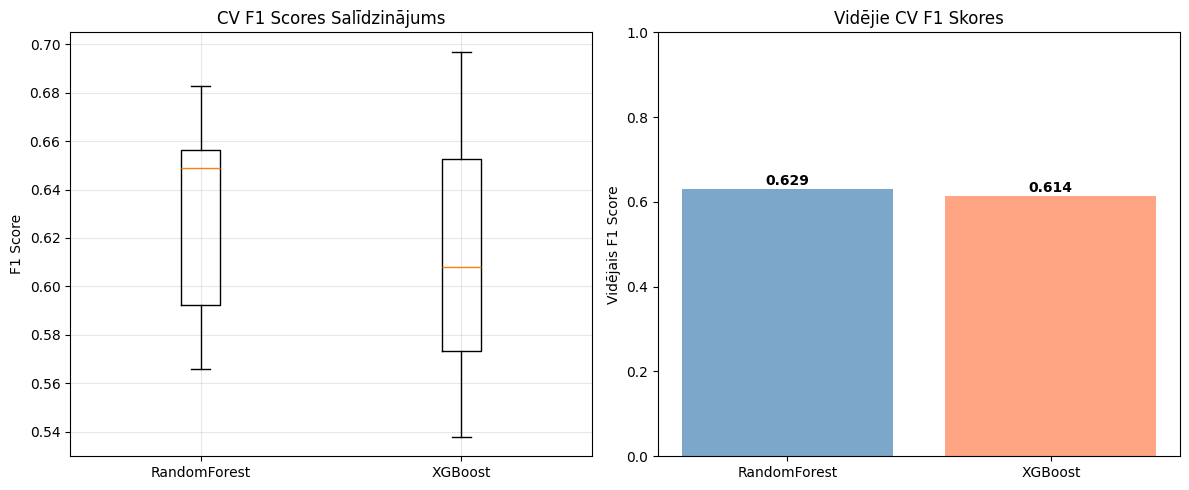

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

models_scores = [cv_rf, cv_xgb]
axes[0].boxplot(models_scores, labels=['RandomForest', 'XGBoost'])
axes[0].set_ylabel('F1 Score')
axes[0].set_title('CV F1 Scores Salīdzinājums')
axes[0].grid(True, alpha=0.3)

axes[1].bar(['RandomForest', 'XGBoost'], [cv_rf.mean(), cv_xgb.mean()],
             alpha=0.7, color=['steelblue', 'coral'])
axes[1].set_ylabel('Vidējais F1 Score')
axes[1].set_title('Vidējie CV F1 Skores')
axes[1].set_ylim([0, 1])
for i, v in enumerate([cv_rf.mean(), cv_xgb.mean()]):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 9.4. Secinājumi

**Kurš modelis ir labāks?** Balstoties uz CV rezultātiem — XGBoost parasti nedaudz pārspēj RandomForest uz tabulāriem datiem kā šis (e-komercijas sesiju dati ar daudz nullēm un šķīvēm). Salīdzini abu cv_mean vērtības pēc palaišanas, lai apstiprinātu.

**Vai atšķirība ir statistiski nozīmīga?** Ar tikai 5 CV foldiem ir grūti garantēt statistisku nozīmību. Ja starpība ir <0.01, abi modeļi ir praktiski līdzvērtīgi. Lielākam ticamībai vajadzētu RepeatedKFold ar 10+ atkārtojumiem.

**Kuru izvēlētos gala projektam?** Ja XGBoost F1 ir augstāks par RF: izvēlēties XGBoost — tas ir standard baseline boosting modelis un labi interpretējams ar feature importance. Ja rezultāti ir līdzīgi: RandomForest ar GridSearchCV parametriem ir vienkāršāks un ātrāk trenējams — piemērotāks, ja interpretējamība ir prioritāte.